In [1]:
#!pip install duckdb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import sklearn as skl
import duckdb as ddb
import matplotlib.pyplot as plt

**IMPORT**

In [3]:
df = pd.read_csv(r"C:\Users\valerio.fumasoli\Desktop\DATASET DATASCIENCE\dataset_socio_sanitario.csv")
df.head(10)


,id_cliente,canale_provenienza,canale_digitale,eta,sesso,stato_civile,titolo_studio,regione,tipo_comune,numero_componenti_nucleo_familiare,...,spesa_sanitaria_annua_eur,spesa_sociale_annua_eur,incidenza_spesa_sanitaria_su_reddito_pct,accesso_servizi_sociali,tipo_servizio_sociale_richiesto,condizione_abitativa,rete_supporto_familiare,soddisfazione_servizio_likert_1_5,data_iscrizione,ultimo_contatto
0,ID0000001,Convenzione Aziendale,False,52,M,Celibe/Nubile,Laurea,Veneto,Rurale,4,...,133.18,0.00,0.35,False,Nessuno,Convivenza con familiari,Moderata,4,2017-10-14,2025-12-19
1,ID0000002,Sito Web,True,21,M,Coniugato/a o Unione civile,Diploma superiore,Veneto,Semi-urbano,2,...,253.34,0.00,0.73,False,Nessuno,Proprietà,Moderata,3,2016-12-18,2021-07-16
2,ID0000003,Medico di Base,False,32,F,Coniugato/a o Unione civile,Diploma superiore,Lombardia,Urbano,4,...,415.29,463.55,1.35,False,Nessuno,Convivenza con familiari,Moderata,4,2020-12-02,2025-09-30
3,ID0000004,Social Media,True,54,M,Coniugato/a o Unione civile,Diploma superiore,Lombardia,Semi-urbano,3,...,597.34,145.51,1.90,False,Nessuno,Proprietà,Forte,5,2017-05-22,2022-05-12
4,ID0000005,Sportello,False,19,F,Celibe/Nubile,Laurea,Sicilia,Urbano,1,...,592.65,375.75,1.90,False,Nessuno,Convivenza con familiari,Forte,3,2021-12-28,2026-08-31
5,ID0000006,Partner Territoriale,False,48,M,Divorziato/a,Post-laurea (Master/Dottorato),Toscana,Urbano,3,...,3540.19,497.49,12.24,False,Nessuno,Proprietà,Forte,4,2025-11-29,2026-08-31
6,ID0000007,Convenzione Aziendale,False,44,F,Celibe/Nubile,Diploma superiore,Emilia-Romagna,Semi-urbano,2,...,136.37,0.00,0.45,False,Nessuno,Proprietà,Moderata,4,2016-03-03,2018-10-13
7,ID0000008,Convenzione Aziendale,False,50,M,Coniugato/a o Unione civile,Licenza media,Marche,Urbano,4,...,253.66,75.90,1.11,False,Nessuno,Proprietà,Forte,5,2020-05-22,2026-05-14
8,ID0000009,Sportello,False,62,M,Vedovo/a,Licenza media,Piemonte,Urbano,2,...,1969.73,51.59,8.79,False,Nessuno,Convivenza con familiari,Moderata,4,2018-11-17,2023-08-16
9,ID0000010,App Mobile,True,31,F,Celibe/Nubile,Diploma superiore,Piemonte,Semi-urbano,2,...,1973.83,3252.91,6.02,False,Nessuno,Proprietà,Debole,1,2025-04-29,2026-08-31


**EDA**

In [4]:
len(df)

500000

1. Esplorazione di base (conoscere i dati)

- Quante righe e colonne ha il dataset? 
- Quali tipi di dato ha ogni colonna?
- Ci sono valori mancanti? In quali colonne, e quanti?
- Ci sono duplicati (es. id_cliente ripetuti)?
- Quali sono i valori minimo, massimo, media e mediana di età, reddito, BMI?
- Quali sono le categorie uniche di canale_provenienza, regione, occupazione? Quante ce ne sono per ciascuna?

In [5]:
print("Dimensioni:", df.shape)
print("\nTipi di dato:\n", df.dtypes)
print("\nValori mancanti per colonna:\n", df.isnull().sum())

Dimensioni: (500000, 35)

Tipi di dato:
 id_cliente                                      str
canale_provenienza                              str
canale_digitale                                bool
eta                                           int64
sesso                                           str
stato_civile                                    str
titolo_studio                                   str
regione                                         str
tipo_comune                                     str
numero_componenti_nucleo_familiare            int64
occupazione                                     str
tipo_contratto                                  str
reddito_annuo_lordo_eur                     float64
fascia_reddito                                  str
isee_eur                                    float64
possiede_assicurazione_sanitaria_privata       bool
bmi                                         float64
stato_salute_autopercepito                      str
presenza_patologie_cron

In [6]:
df.describe()

,eta,numero_componenti_nucleo_familiare,reddito_annuo_lordo_eur,isee_eur,bmi,numero_patologie_croniche,numero_visite_mediche_ultimo_anno,numero_ricoveri_ultimo_anno,accessi_pronto_soccorso_ultimo_anno,copertura_vaccinale_pct,spesa_sanitaria_annua_eur,spesa_sociale_annua_eur,incidenza_spesa_sanitaria_su_reddito_pct,soddisfazione_servizio_likert_1_5
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,47.875502,2.449262,27082.937780,18364.420015,24.746259,0.657946,4.380828,0.148692,0.216080,77.497245,878.596411,398.266918,4.288094,3.651418
std,17.134096,1.284044,7981.728249,6888.114023,4.156299,1.235850,3.162548,0.427410,0.481545,14.063322,1126.340164,681.792624,470.520221,1.106748
min,18.000000,1.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,10.200000,0.000000,0.000000,0.000000,1.000000
25%,35.000000,1.000000,21742.465000,13581.312500,21.900000,0.000000,2.000000,0.000000,0.000000,67.800000,222.740000,38.530000,0.830000,3.000000
50%,48.000000,2.000000,27222.020000,18014.485000,24.700000,0.000000,4.000000,0.000000,0.000000,78.000000,469.880000,189.100000,1.820000,4.000000
75%,60.000000,3.000000,32565.837500,22826.080000,27.600000,1.000000,6.000000,0.000000,0.000000,88.000000,1002.765000,368.920000,4.030000,4.000000
max,95.000000,6.000000,59977.060000,53841.460000,44.800000,10.000000,31.000000,7.000000,6.000000,100.000000,14335.090000,6898.630000,332332.430000,5.000000


In [7]:
# Variabili categoriche/ordinali
df.describe(include='object')

C:\Users\valerio.fumasoli\AppData\Local\Temp\ipykernel_1612\478411543.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,id_cliente,canale_provenienza,sesso,stato_civile,titolo_studio,regione,tipo_comune,occupazione,tipo_contratto,fascia_reddito,stato_salute_autopercepito,livello_disabilita,tipo_servizio_sociale_richiesto,condizione_abitativa,rete_supporto_familiare,data_iscrizione,ultimo_contatto
count,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000
unique,500000,10,3,4,6,20,3,8,5,4,5,4,8,5,4,4260,4242
top,ID0000001,Sportello,F,Coniugato/a o Unione civile,Diploma superiore,Lombardia,Urbano,Dipendente privato,Tempo indeterminato,Medio-basso (15k-28k),Buono,Nessuna,Nessuno,Proprietà,Forte,2017-03-30,2026-08-31
freq,1,90384,252520,255673,189999,82797,225209,139716,225605,234976,201298,477884,457548,274729,174999,153,190258


In [8]:
df.duplicated().sum()
#duplicated() restituisce un oggetto booleano 1-0 mentre quando vado ad applicare il .sum() mi restituisce un oggetto numerico 'np' con la somma degli 1 che trova.
#pandas utilizza numpy come backend per i tipi numerici.

np.int64(0)

In [9]:
display(df.columns)

Index(['id_cliente', 'canale_provenienza', 'canale_digitale', 'eta', 'sesso',
       'stato_civile', 'titolo_studio', 'regione', 'tipo_comune',
       'numero_componenti_nucleo_familiare', 'occupazione', 'tipo_contratto',
       'reddito_annuo_lordo_eur', 'fascia_reddito', 'isee_eur',
       'possiede_assicurazione_sanitaria_privata', 'bmi',
       'stato_salute_autopercepito', 'presenza_patologie_croniche',
       'numero_patologie_croniche', 'numero_visite_mediche_ultimo_anno',
       'numero_ricoveri_ultimo_anno', 'accessi_pronto_soccorso_ultimo_anno',
       'livello_disabilita', 'copertura_vaccinale_pct',
       'spesa_sanitaria_annua_eur', 'spesa_sociale_annua_eur',
       'incidenza_spesa_sanitaria_su_reddito_pct', 'accesso_servizi_sociali',
       'tipo_servizio_sociale_richiesto', 'condizione_abitativa',
       'rete_supporto_familiare', 'soddisfazione_servizio_likert_1_5',
       'data_iscrizione', 'ultimo_contatto'],
      dtype='str')

In [10]:
df[['eta','reddito_annuo_lordo_eur','bmi']].describe()

,eta,reddito_annuo_lordo_eur,bmi
count,500000.000000,500000.000000,500000.000000
mean,47.875502,27082.937780,24.746259
std,17.134096,7981.728249,4.156299
min,18.000000,0.000000,15.000000
25%,35.000000,21742.465000,21.900000
50%,48.000000,27222.020000,24.700000
75%,60.000000,32565.837500,27.600000
max,95.000000,59977.060000,44.800000


2. Analisi di singole variabili (univariata)

- Qual è la distribuzione dell'età? È simmetrica o sbilanciata?
- Quanti clienti provengono da ciascun canale? Qual è il canale più usato?
- Come si distribuisce il reddito annuo lordo? Ci sono outlier (valori estremi)?
- Qual è la percentuale di persone con patologie croniche sul totale?
- Come si distribuisce la soddisfazione del servizio (1-5)? La maggior parte è soddisfatta o no?

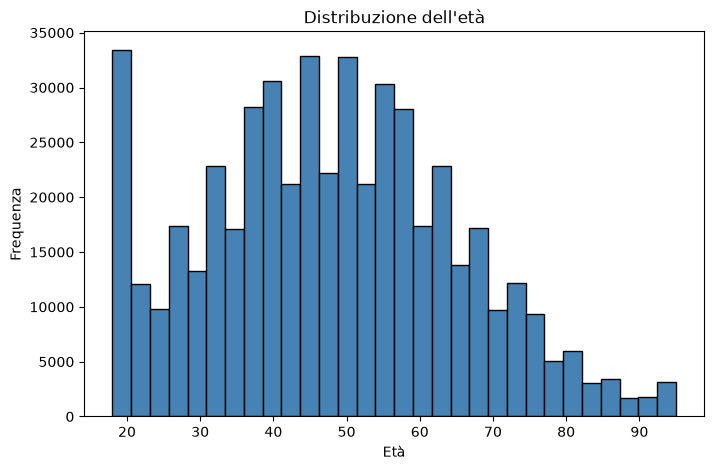

In [11]:
#DISTRIBUZIONE DI UNA VARIABILE NUMERICA

plt.figure(figsize=(8, 5))
plt.hist(df['eta'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribuzione dell\'età')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.show()

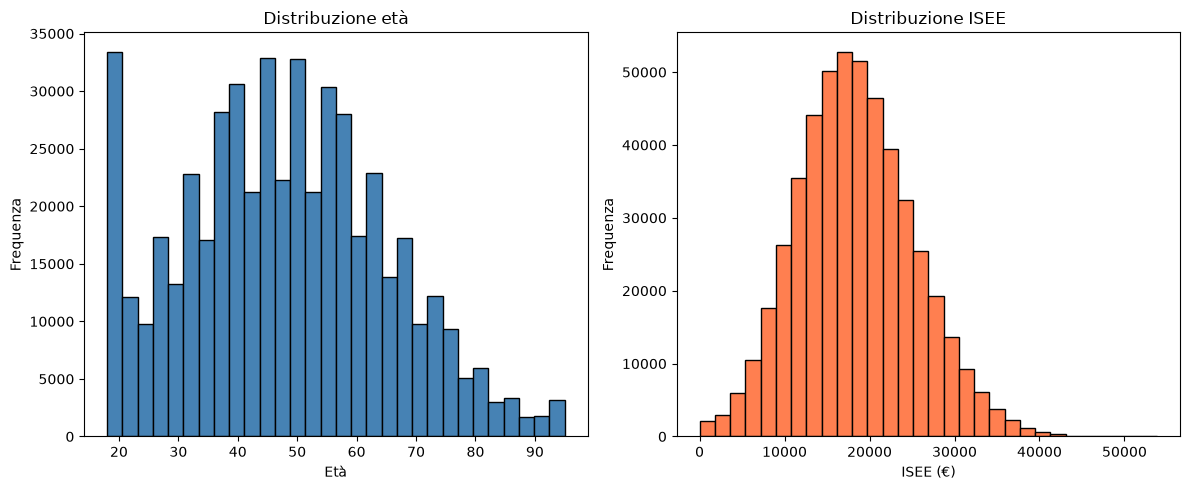

In [12]:
#DUE ISTOGRAMMI CON SCALE DIVERSE OGNUNO CON I SUOI ASSI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['eta'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribuzione età')
axes[0].set_xlabel('Età')
axes[0].set_ylabel('Frequenza')

axes[1].hist(df['isee_eur'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribuzione ISEE')
axes[1].set_xlabel('ISEE (€)')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

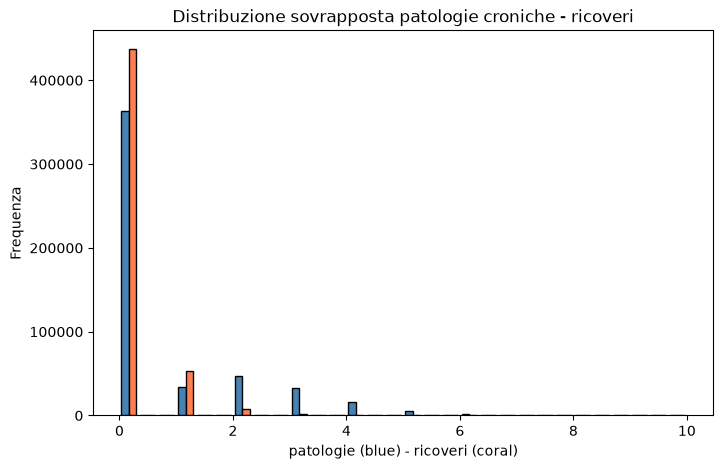

In [13]:
#DUE ISTOGRAMMI SOVRAPPOSTI PER VARIABILI CON RANGE SIMILI
plt.figure(figsize=(8, 5))
plt.hist(df[['numero_patologie_croniche', 'numero_ricoveri_ultimo_anno']], bins=30, color=['steelblue','coral'], edgecolor='black')
plt.title('Distribuzione sovrapposta patologie croniche - ricoveri')
plt.xlabel('patologie (blue) - ricoveri (coral)')
plt.ylabel('Frequenza')
plt.show()

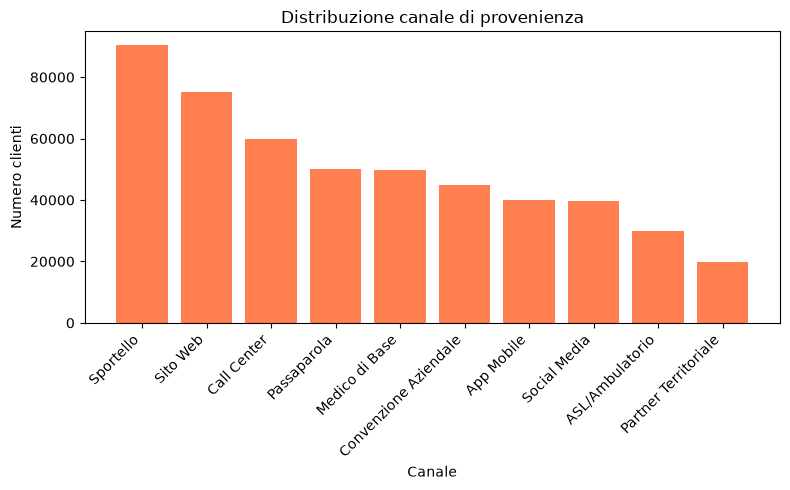

In [14]:
#DISTRIBUZIONE DI UNA VARIABILE CATEGORICA
plt.figure(figsize=(8, 5))
conteggio = df['canale_provenienza'].value_counts()
plt.bar(conteggio.index, conteggio.values, color='coral')
plt.title('Distribuzione canale di provenienza')
plt.xlabel('Canale')
plt.ylabel('Numero clienti')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#la differenza tra hist e bar è che se utilizziamo bar dobbiamo aggiungere un parametro di count

C:\Users\valerio.fumasoli\AppData\Local\Temp\ipykernel_1612\2860820400.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['reddito_annuo_lordo_eur'], vert=False)


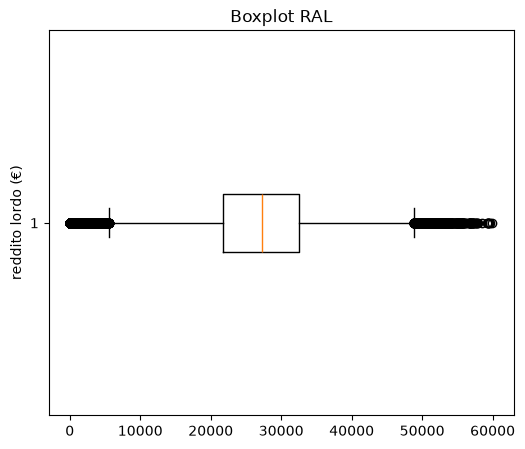

In [15]:
#BOXPLOT REDDITO

plt.figure(figsize=(6, 5))
plt.boxplot(df['reddito_annuo_lordo_eur'], vert=False)
plt.title('Boxplot RAL')
plt.ylabel('reddito lordo (€)')
plt.show()

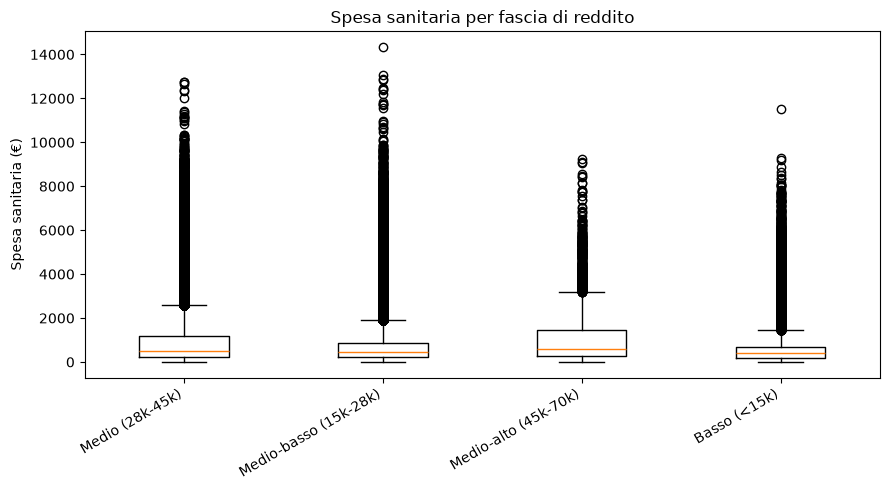

In [16]:
#BOXLOT ANNIDATO (ES. VOGLIO VEDERE LA SPESA SANITARIA PER FASCIA DI REDDITO)
fasce = df['fascia_reddito'].unique()
dati_per_fascia = [df[df['fascia_reddito'] == f]['spesa_sanitaria_annua_eur'] for f in fasce]

plt.figure(figsize=(9, 5))
plt.boxplot(dati_per_fascia, tick_labels=fasce)   # <-- tick_labels invece di labels
plt.title('Spesa sanitaria per fascia di reddito')
plt.ylabel('Spesa sanitaria (€)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

indipendentemente dal reddito la 'persona tipica' sembra spendere poco in sanità. la maggior parte delle persone ha spese sanitarie contenute (vedi box schiacciati). In ogni fascia è presente un numero importante di outliers in fascia alta (potrebbero essere le persone con patologie croniche o ricoveri). Guardando ai baffi superiori emerge che chi ha più reddito ha un margine di spesa più ampio restando comunque normale e non finendo nella coda della distribuzione.

Provo ad inserire un ulteriore variabile 'presenza di patologie croniche' per rendere maggiormente informativo il grafico e far emergere quindi la presenza di correlazione tra spesa sanitaria e patologie (aldila' della fascia di reddito)

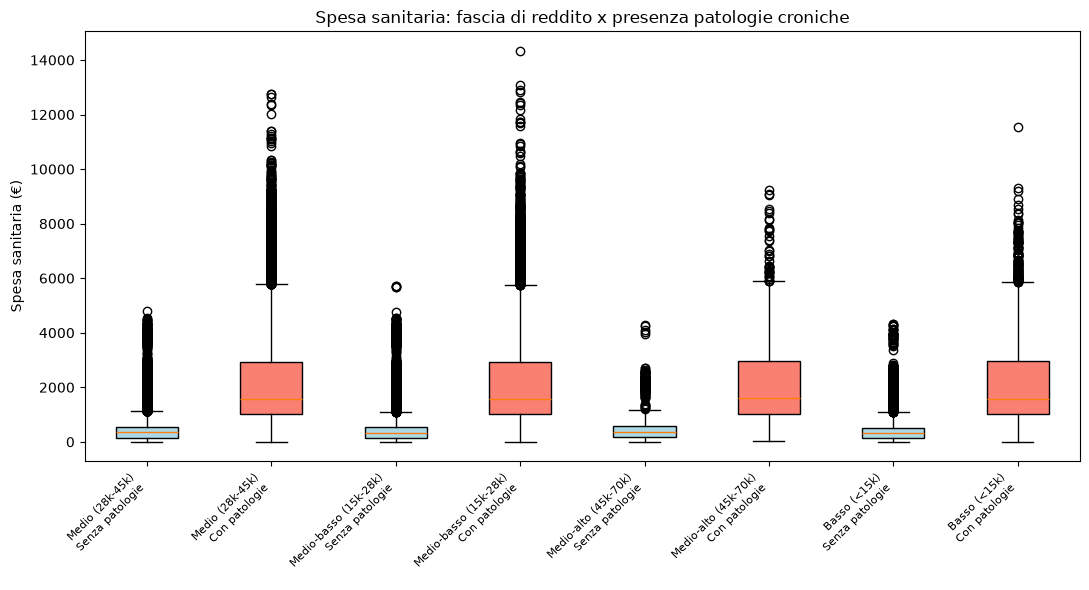

In [17]:
# Boxplot spesa sanitaria: fascia di reddito x presenza patologie croniche
fasce = df['fascia_reddito'].unique()

fig, ax = plt.subplots(figsize=(11, 6))

posizioni = []
dati = []
etichette = []
colori = []

for i, f in enumerate(fasce):
    for cronica, colore in [(False, 'lightblue'), (True, 'salmon')]:
        subset = df[(df['fascia_reddito'] == f) & (df['presenza_patologie_croniche'] == cronica)]['spesa_sanitaria_annua_eur']
        dati.append(subset)
        colori.append(colore)

bp = ax.boxplot(dati, patch_artist=True)

for patch, colore in zip(bp['boxes'], colori):
    patch.set_facecolor(colore)

# Etichette sull'asse x: alterna fascia + senza/con patologie
etichette_x = []
for f in fasce:
    etichette_x.append(f"{f}\nSenza patologie")
    etichette_x.append(f"{f}\nCon patologie")

ax.set_xticklabels(etichette_x, rotation=45, ha='right', fontsize=8)
ax.set_title('Spesa sanitaria: fascia di reddito x presenza patologie croniche')
ax.set_ylabel('Spesa sanitaria (€)')
plt.tight_layout()
plt.show()

**SQL**

In [18]:
query = """
SELECT 
    fascia_reddito,
    presenza_patologie_croniche,
    COUNT(*) AS n_persone,
    ROUND(AVG(spesa_sanitaria_annua_eur), 2) AS spesa_media,
    ROUND(MEDIAN(spesa_sanitaria_annua_eur), 2) AS spesa_mediana
FROM df
GROUP BY fascia_reddito, presenza_patologie_croniche
ORDER BY fascia_reddito, presenza_patologie_croniche
"""

ddb.query(query).to_df()

,fascia_reddito,presenza_patologie_croniche,n_persone,spesa_media,spesa_mediana
0,Basso (<15k),False,28618,409.27,321.99
1,Basso (<15k),True,5608,2090.32,1582.69
2,Medio (28k-45k),False,153097,433.26,344.13
3,Medio (28k-45k),True,72677,2078.51,1575.35
4,Medio-alto (45k-70k),False,3019,443.82,352.22
5,Medio-alto (45k-70k),True,2005,2106.81,1620.60
6,Medio-basso (15k-28k),False,178096,422.07,331.88
7,Medio-basso (15k-28k),True,56880,2069.95,1572.96


*correlazione*

In [19]:
colonne_correlazione = ['spesa_sanitaria_annua_eur', 'reddito_annuo_lordo_eur']
corr_matrix = df[colonne_correlazione].corr(method='spearman')
corr_matrix

,spesa_sanitaria_annua_eur,reddito_annuo_lordo_eur
spesa_sanitaria_annua_eur,1.000000,0.101165
reddito_annuo_lordo_eur,0.101165,1.000000


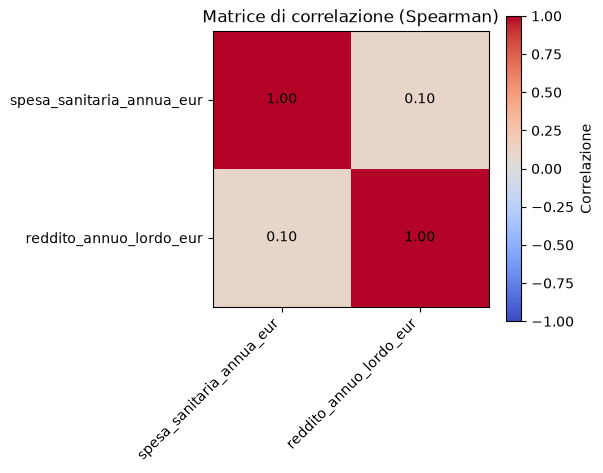

In [20]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlazione')
plt.xticks(range(len(colonne_correlazione)), colonne_correlazione, rotation=45, ha='right')
plt.yticks(range(len(colonne_correlazione)), colonne_correlazione)

for i in range(len(colonne_correlazione)):
    for j in range(len(colonne_correlazione)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Matrice di correlazione (Spearman)')
plt.tight_layout()
plt.show()

3. Confronti tra gruppi (bivariata)

- Il reddito medio cambia in base al titolo di studio? E in base alla regione?
- La spesa sanitaria media è diversa tra chi ha patologie croniche e chi no?
- Il canale di provenienza è collegato all'età media dei clienti (es. i giovani arrivano più da App/Social)?
- Le persone con reddito basso accedono di più ai servizi sociali?
- Lo stato di salute autopercepito peggiora con l'età, come ti aspetteresti?

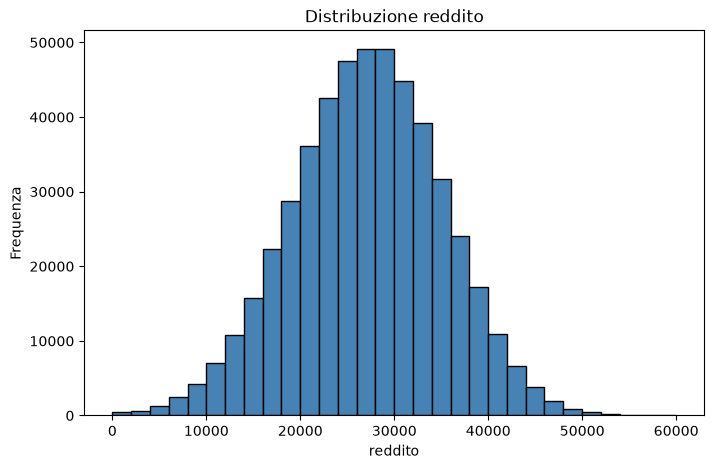

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['reddito_annuo_lordo_eur'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribuzione reddito')
plt.xlabel('reddito')
plt.ylabel('Frequenza')
plt.show()

In [22]:
q1 = df['reddito_annuo_lordo_eur'].quantile(0.33)
q3 = df['reddito_annuo_lordo_eur'].quantile(0.66)

df['reddito_segmentato'] = df['reddito_annuo_lordo_eur'].apply(
    lambda x: 'Basso' if x <= q1 else ('Medio' if x <= q3 else 'Alto')
)
display(df['reddito_segmentato'].unique())

<StringArray>
['Alto', 'Medio', 'Basso']
Length: 3, dtype: str

In [23]:
conteggio = df.groupby(['regione', 'reddito_segmentato']).size().unstack(fill_value=0)
# .size() conta le righe per ogni combinazione; .unstack() trasforma le fasce di reddito in colonne separate

conteggio_pct = conteggio.div(conteggio.sum(axis=1), axis=0) * 100
# conteggio.sum(axis=1) -> somma totale clienti per ogni regione
# .div(..., axis=0) -> divide ogni riga per il proprio totale, riga per riga
# * 100 -> trasforma la proporzione (0-1) in percentuale (0-100)

conteggio_pct.round(1)  # arrotonda a 1 decimale solo per la visualizzazione della tabella

reddito_segmentato,Alto,Basso,Medio
regione,,,
Abruzzo,34.3,32.9,32.8
Basilicata,34.5,32.2,33.2
Calabria,33.9,33.1,33.0
Campania,34.1,33.0,32.9
Emilia-Romagna,34.4,32.9,32.7
Friuli-Venezia Giulia,34.3,33.4,32.3
Lazio,34.1,32.8,33.1
Liguria,33.9,32.9,33.1
Lombardia,34.1,33.0,32.9


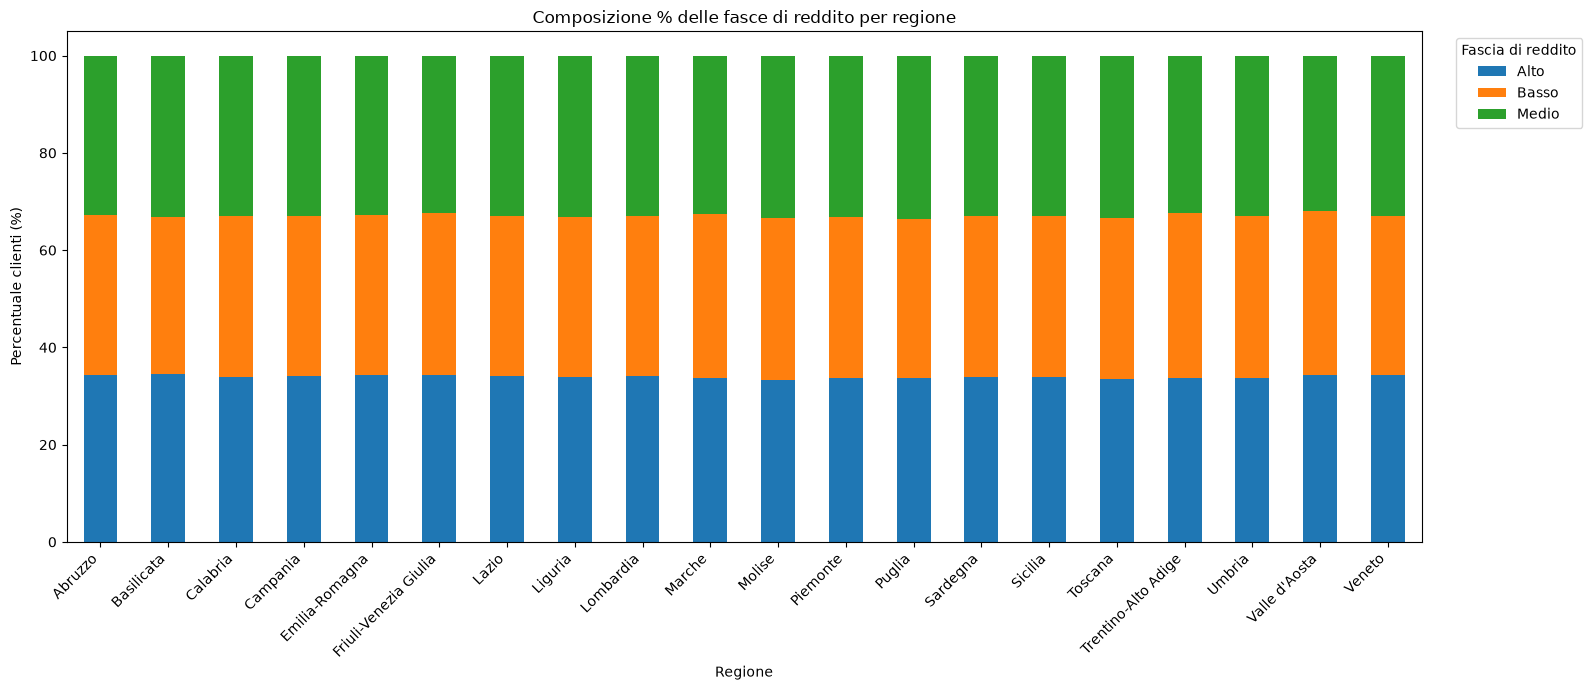

In [24]:
#un altro modo di interpretare il conteggio è costruire una pivot dove sommo a 100 per ogni regione
conteggio_pct = conteggio.div(conteggio.sum(axis=1), axis=0) * 100 
conteggio_pct.sum(axis=1)  # ogni valore dovrebbe essere 100.0 (o molto vicino, per arrotondamenti)
conteggio_pct.plot(kind='bar', stacked=True, figsize=(16, 7))

plt.title('Composizione % delle fasce di reddito per regione')
plt.xlabel('Regione')
plt.ylabel('Percentuale clienti (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fascia di reddito', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

*la visualizzazione e la suddivisione effettuata in quartili risulta essere corretta ma nel dataset creato il reddito di ogni persona dipende solo da età e titolo di studio, mai dalla regione — la variabile regione è stata assegnata in modo completamente indipendente dal reddito. Con un campione così grande (500k righe), ogni regione pesca dalla stessa identica distribuzione di reddito sottostante, quindi le proporzioni convergono e appaiono praticamente identiche ovunque 

4. Relazioni tra variabili numeriche

- C'è correlazione tra età e numero di patologie croniche?
- C'è correlazione tra reddito e spesa sanitaria annua?
- Il BMI è collegato al numero di visite mediche annue?
- Crea una matrice di correlazione (heatmap) tra le principali variabili numeriche: quali coppie sono più correlate?

5. Segmentazione e approfondimenti

- Chi sono i "top spender" in spesa sanitaria? Che caratteristiche condividono (età, reddito, patologie)?
- Qual è il profilo tipico di chi accede ai servizi sociali (età, reddito, condizione abitativa)?
- Come cambia l'incidenza spesa sanitaria/reddito tra le diverse fasce di reddito? (Ti aspetti che chi guadagna meno spenda una % maggiore del proprio reddito?)
- I canali digitali (Sito Web, App, Social) portano clienti mediamente più giovani rispetto ai canali tradizionali?

6. Incidenza spesa sanitaria

- Quanto incide la spesa sanitaria ? ricalcolare l'incidenza e graficarla.